In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df_tg = pd.read_csv('df_tg.csv')
df_hh = pd.read_csv('df_hh.csv')

In [7]:
df_hh = df_hh.drop_duplicates(subset=['description'], keep='first').reset_index(drop=True)
len(df_hh)

1117

In [8]:
len(df_tg)

2892

In [9]:
cols = ['source', 'date', 'text', 'salary_from', 'salary_to', 'salary_mid', 'is_high_salary', 'grade', 'work_format', 'technologies', 'specialization']

In [10]:
df = pd.concat([df_tg[cols], df_hh[cols]], ignore_index=True)
df

,source,date,text,salary_from,salary_to,salary_mid,is_high_salary,grade,work_format,technologies,specialization
0,telegram,2025-02-10 09:09:31,Публикатор: Nelly🍒\nОбсуждение вакансии в чате...,420000.0,NaN,420000.0,True,senior,remote,"Python, Go, R, Docker, Kubernetes, Terraform, ...",DevOps/SRE
1,telegram,2025-02-12 12:51:07,Публикатор: Анастасия Патрикеева\nОбсуждение в...,280000.0,400000.0,340000.0,False,NaN,remote,"R, SQL, MySQL, MSSQL, Docker, Kubernetes, Ansi...",DevOps/SRE
2,telegram,2025-02-12 12:51:35,Публикатор: Даниэлла Котовская🖤\nОбсуждение ва...,440000.0,NaN,440000.0,True,middle,remote,"Go, R, SQL, Redis, Kafka, Vite, Docker, Kubern...",DevOps/SRE
3,telegram,2025-02-12 17:08:23,Публикатор: Елизавета Бондарева 🌷\nОбсуждение ...,200000.0,400000.0,300000.0,False,NaN,hybrid,"Python, R, Bash, SQL, PostgreSQL, Ansible, Jen...",DevOps/SRE
4,telegram,2025-02-13 09:54:27,Публикатор: Margarita Ivanishcheva\nОбсуждение...,300000.0,400000.0,350000.0,False,junior,remote,"Python, Java, Go, C++, C#, R, Node.js, Docker,...",DevOps/SRE
...,...,...,...,...,...,...,...,...,...,...,...
4004,hh_ru,2026-03-12 16:42:10,Дизайнер интерьеров в офис (м.Новокузнецкая) E...,150000.0,250000.0,200000.0,False,NaN,office,Excel,Architect
4005,hh_ru,2026-03-12 11:27:01,Дизайнер «OLEXDECO» ™ один из наиболее динамич...,80000.0,NaN,80000.0,False,NaN,office,Git,UX/UI Designer
4006,hh_ru,2026-03-11 20:02:15,Графический дизайнер + СММ (специалист по марк...,150000.0,NaN,150000.0,False,NaN,remote,Git,UX/UI Designer
4007,hh_ru,2026-03-10 08:30:23,"UX/UI-дизайнер Рекламное агентство ""Advline"" в...",100000.0,NaN,100000.0,False,NaN,remote,CSS,UX/UI Designer


In [14]:
df.to_csv('df.csv')

In [16]:
channels_info = pd.read_csv('channels_info.csv')
total_messages = pd.read_csv('total_messages_count.csv')

In [18]:
channels = channels_info.merge(total_messages, on='channel')
channels = channels.sort_values('members_count', ascending=False).reset_index()
channels

,index,channel,title,description,members_count,total_messages
0,5,analysts_hunter,Работа ищет аналитиков // Вакансии,Правила размещения вакансий: https://teletype....,25055,191511
1,3,zrabota,АйТи Вакансии. ИИ Работа. Фриланс. Удаленка,Свежие АйТи/Диджитал вакансии каждый день по р...,21684,1193
2,1,devops_jobs_feed,Devops Jobs — вакансии и резюме,Вакансии из @devops_jobs\n\nОстальные каналы: ...,19830,22249
3,4,vacancy_cs,ФКН: Вакансии,"Канал с вакансиями, мероприятиями и хакатонами...",14490,748
4,0,data_hr,Data Analytics Jobs | Вакансии,Канал с вакансиями для специалистов по работе ...,9924,1172
5,2,python_jobs,Python — вакансии и аналитика,Публикуем вакансии и запросы на поиск работы п...,7453,187362


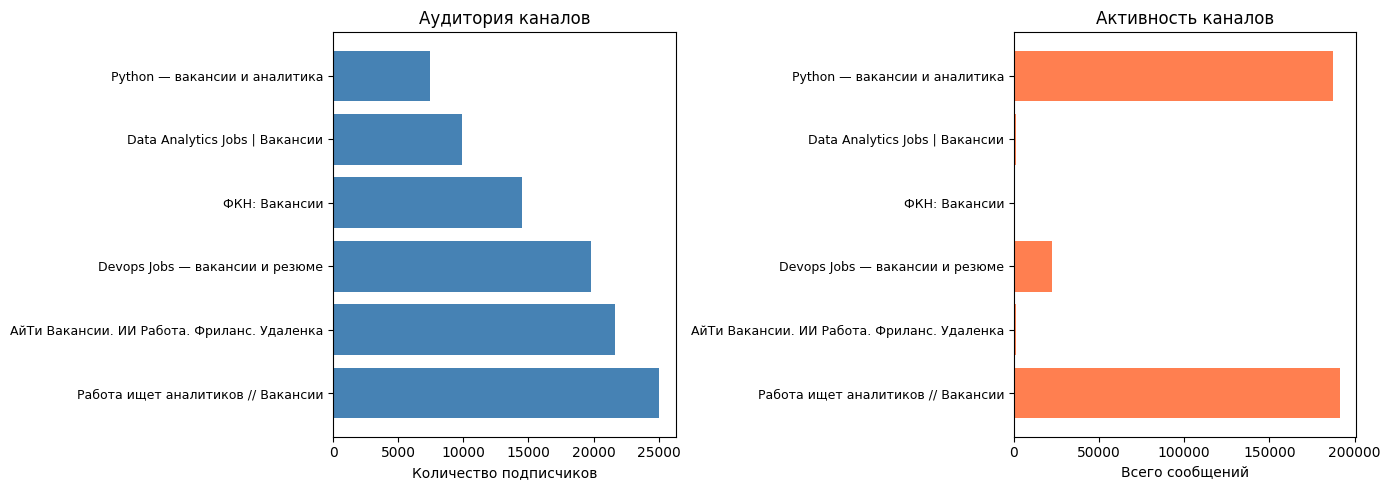

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(channels['title'], channels['members_count'], color='steelblue')
axes[0].set_xlabel('Количество подписчиков')
axes[0].set_title('Аудитория каналов')
axes[0].tick_params(axis='y', labelsize=9)

axes[1].barh(channels['title'], channels['total_messages'], color='coral')
axes[1].set_xlabel('Всего сообщений')
axes[1].set_title('Активность каналов')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

In [24]:
df['specialization'].value_counts(dropna=False)

,count
specialization,
DevOps/SRE,1890
UX/UI Designer,446
Data Analyst,200
Business Analyst,180
ML Engineer,175
Backend Developer,168
System Analyst,136
Data Scientist,135
Data Engineer,129


In [26]:
df = df[df['specialization'] != '1C Developer'].reset_index(drop=True)

In [29]:
df['date'].min()

'2017-10-28 14:35:26'

In [31]:
df = df[df['date'] >= '2025-01-01'].reset_index(drop=True)
len(df)

2470

## Часть первая. Обзор рынка IT-вакансий

Для анализа мы собрали вакансии из двух источников: телеграм каналы с it-вакансиями и платформа hh.ru. Из общего потока объявлений мы
отобрали только it-специальности — вакансии, в которых упоминается хотя бы одна технология из нашего списка (158 инструментов и языков).   

После очистки от нерелевантных объявлений, мусора и дублей наш итоговый датасет содержит 2470 вакансий по 19 it-специализациям. Кроме того, все вакансии содержат указанную зарплату в рублях, это наша целевая переменная. Также мы исследуем только российский рынок труда, период январь 2025 - апрель 2026 года.

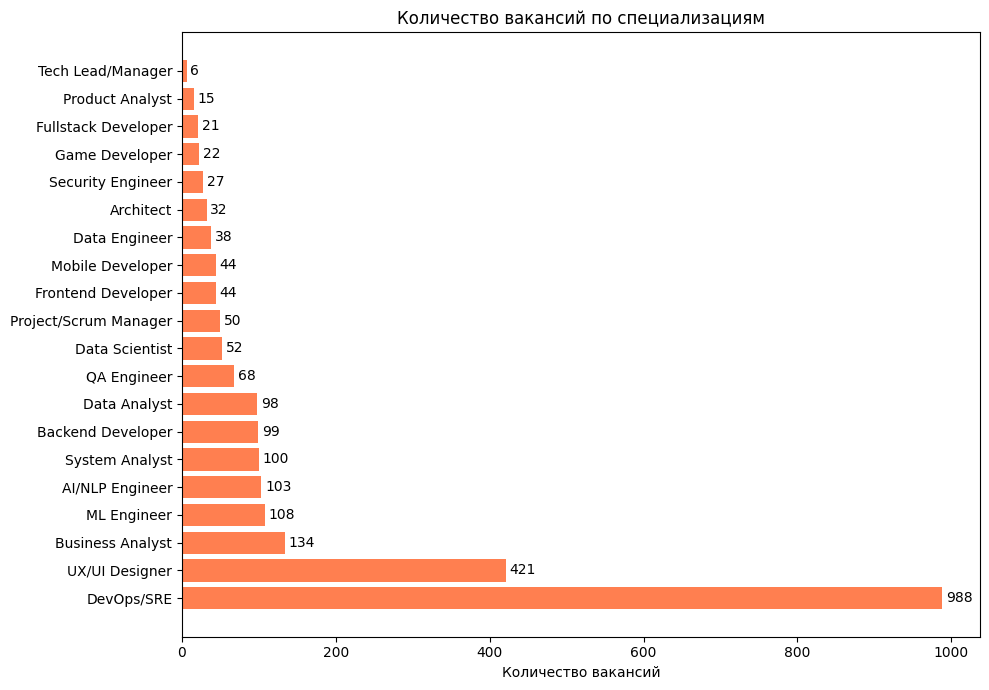

In [57]:
spec_counts = df['specialization'].value_counts().reset_index()
spec_counts.columns = ['specialization', 'count']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(spec_counts['specialization'], spec_counts['count'], color='coral')
ax.set_title('Количество вакансий по специализациям')
ax.set_xlabel('Количество вакансий')

for i, v in enumerate(spec_counts['count']):
  ax.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.show()

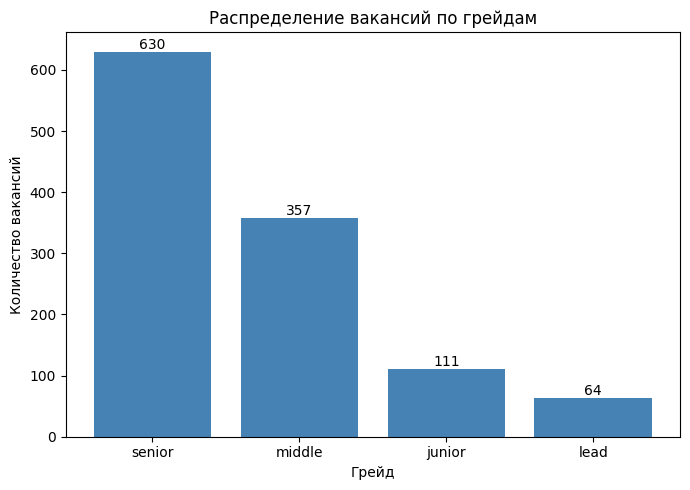

In [58]:
grade_counts = df['grade'].value_counts(dropna=True).reset_index()
grade_counts.columns = ['grade', 'count']

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(grade_counts['grade'].astype(str), grade_counts['count'], color='steelblue')
ax.set_title('Распределение вакансий по грейдам')
ax.set_xlabel('Грейд')
ax.set_ylabel('Количество вакансий')

for i, v in enumerate(grade_counts['count']):
  ax.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

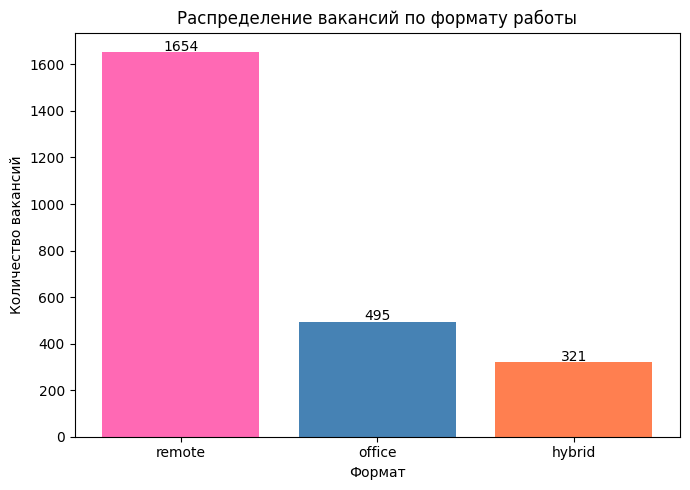

In [59]:
format_counts = df['work_format'].value_counts().reset_index()
format_counts.columns = ['work_format', 'count']

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['hotpink', 'steelblue', 'coral']
ax.bar(format_counts['work_format'], format_counts['count'], color=colors)
ax.set_title('Распределение вакансий по формату работы')
ax.set_xlabel('Формат')
ax.set_ylabel('Количество вакансий')

for i, v in enumerate(format_counts['count']):
  ax.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

## Часть вторая. Анализ зарплат   

Зарплата — это ключевая метрика нашего исследования. Для образовательной платформы важно понимать не только средний уровень дохода по рынку, но и то, как зарплата зависит от специализации, грейда и формата работы.   
Мы используем salary_mid — среднее между нижней и верхней границей вилки. Если вилка не указана, salary_mid равен единственному указанному значению. Это позволяет сравнивать вакансии с вилкой и без неё на одной шкале :)   

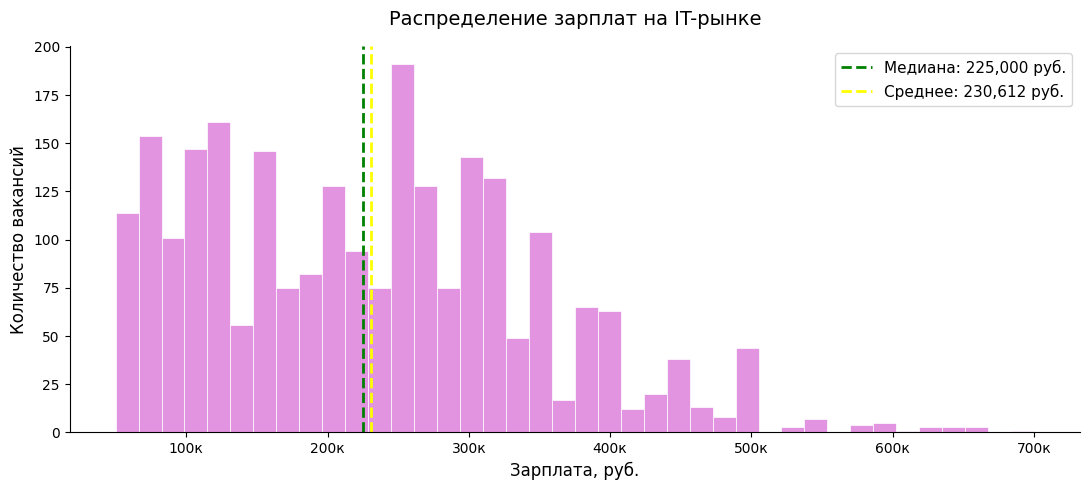

In [60]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(df[df['salary_mid'] <= 700000]['salary_mid'], bins=40, color='orchid', edgecolor='white', linewidth=0.5, ax=ax)

median = df['salary_mid'].median()
mean = df['salary_mid'].mean()

ax.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Медиана: {int(median):,} руб.')
ax.axvline(mean, color='yellow', linestyle='--', linewidth=2, label=f'Среднее: {int(mean):,} руб.')

ax.set_title('Распределение зарплат на IT-рынке', fontsize=14, pad=15)
ax.set_xlabel('Зарплата, руб.', fontsize=12)
ax.set_ylabel('Количество вакансий', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, k: f'{int(x/1000)}к'))

sns.despine()
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

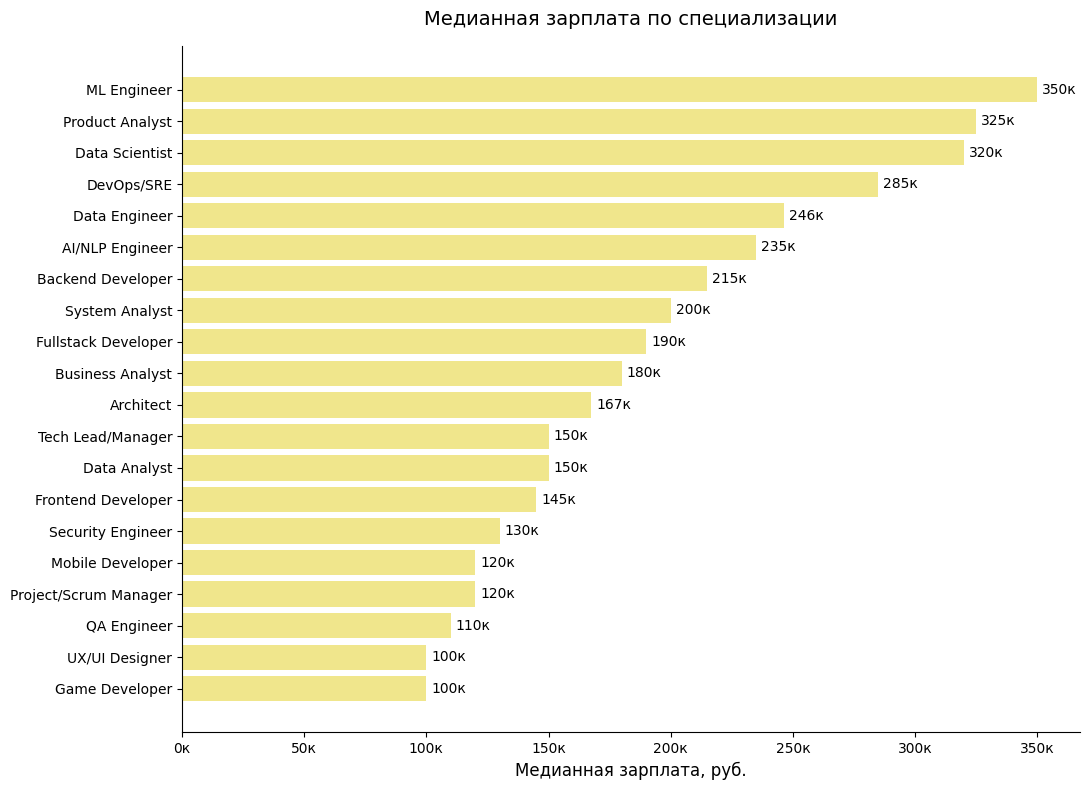

In [61]:
spec_salary = (df.groupby('specialization')['salary_mid'].median().sort_values(ascending=True).reset_index())
spec_salary.columns = ['specialization', 'median_salary']

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(spec_salary['specialization'], spec_salary['median_salary'], color='khaki')

for bar, val in zip(bars, spec_salary['median_salary']):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2,
            f'{int(val/1000)}к', va='center', fontsize=10)

ax.set_title('Медианная зарплата по специализации', fontsize=14, pad=15)
ax.set_xlabel('Медианная зарплата, руб.', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, k: f'{int(x/1000)}к'))

sns.despine()
plt.tight_layout()
plt.show()

## Часть третья. Анализ технологий   

Здесь мы отвечаем на главный вопрос образовательной платформы: чему нужно учить? Мы анализируем 158 технологий, языков и инструментов которые упоминаются в вакансиях. Для каждой технологии считаем востребованность и доходность.


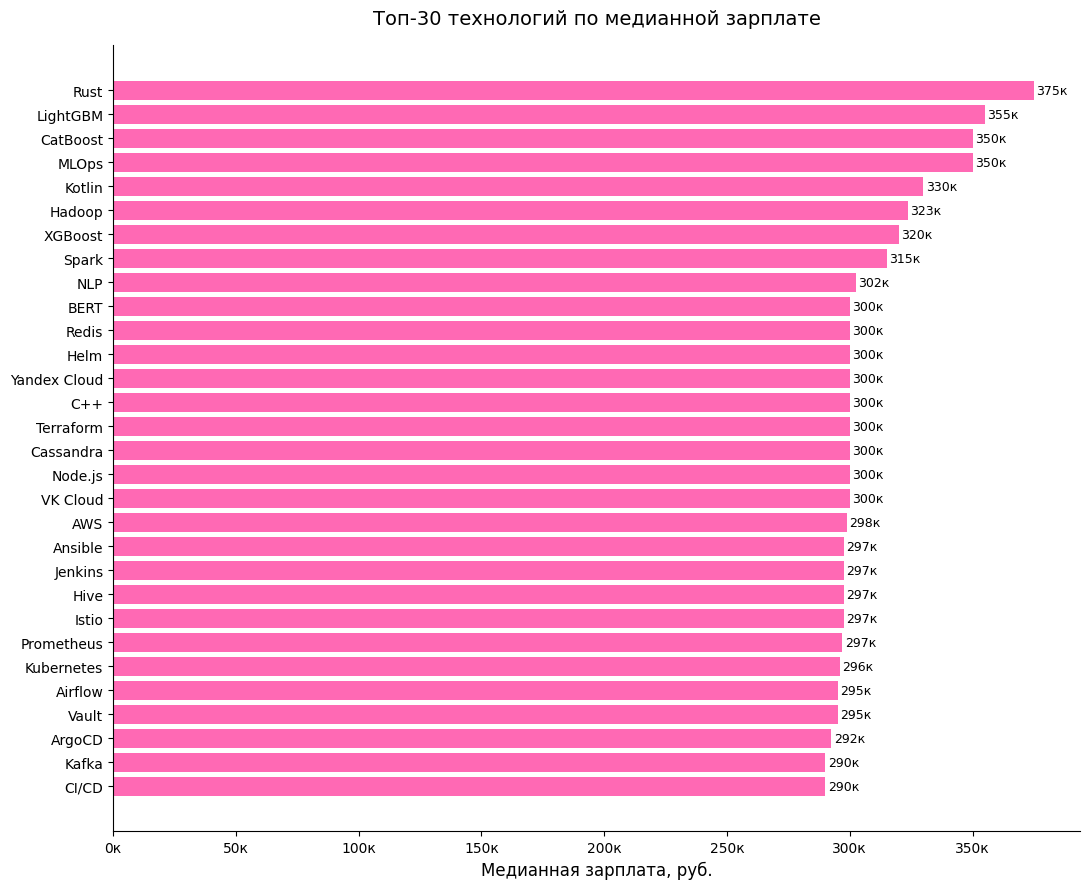

In [62]:
tech_salary = {}

for x, row in df.iterrows():
  for tech in row['technologies'].split(', '):
      if tech not in tech_salary:
          tech_salary[tech] = []
      tech_salary[tech].append(row['salary_mid'])

tech_salary_df = pd.DataFrame([
    {'technology': tech, 'median_salary': pd.Series(salaries).median(), 'count': len(salaries)}
    for tech, salaries in tech_salary.items()
    if len(salaries) >= 10
]).sort_values('median_salary', ascending=True).tail(30)

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(tech_salary_df['technology'], tech_salary_df['median_salary'], color='hotpink')

for bar, val in zip(bars, tech_salary_df['median_salary']):
  ax.text(val + 1000, bar.get_y() + bar.get_height()/2, f'{int(val/1000)}к', va='center', fontsize=9)

ax.set_title('Топ-30 технологий по медианной зарплате', fontsize=14, pad=15)
ax.set_xlabel('Медианная зарплата, руб.', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, k: f'{int(x/1000)}к'))

sns.despine()
plt.tight_layout()
plt.show()

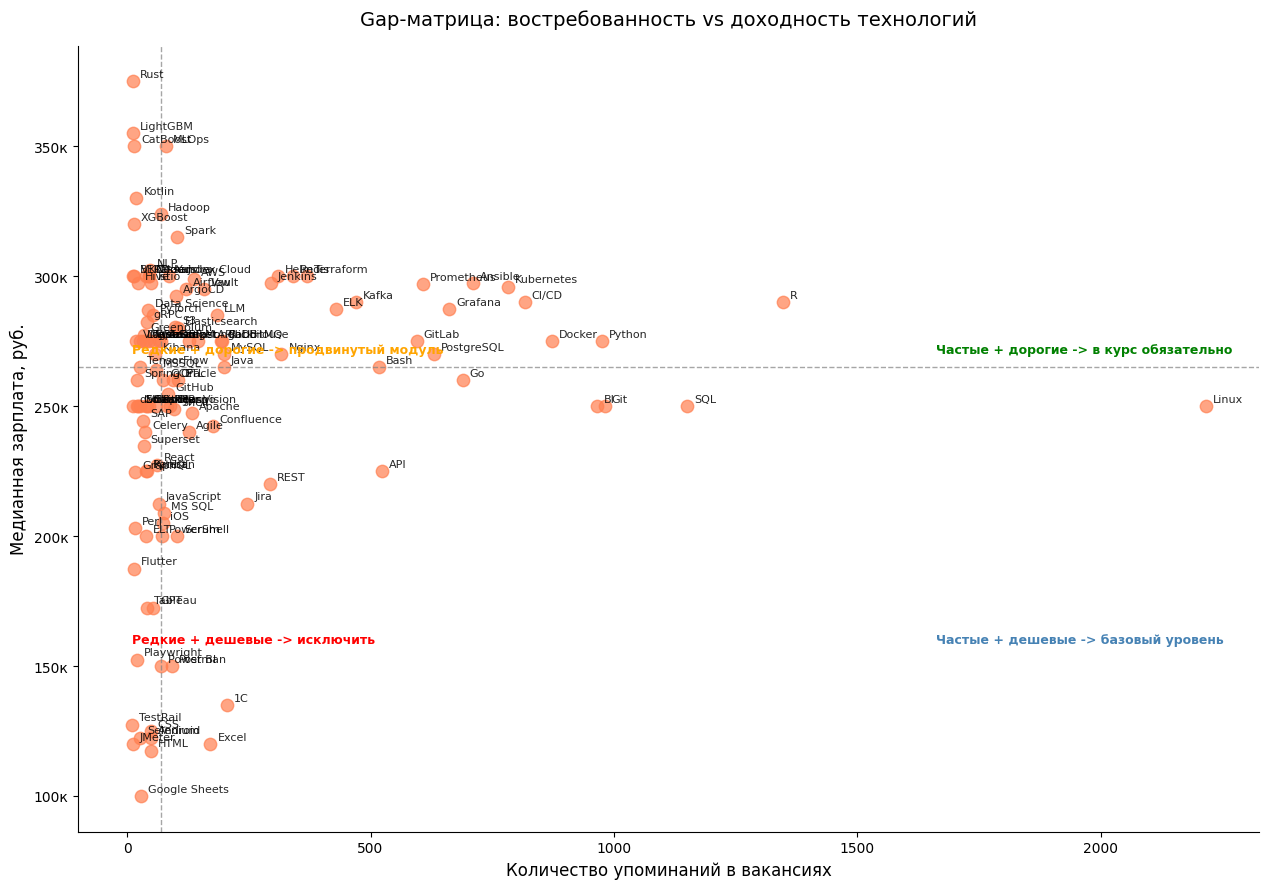

In [63]:
tech_matrix = pd.DataFrame([
    {'technology': tech,
     'count': len(salaries),
     'median_salary': pd.Series(salaries).median()}
    for tech, salaries in tech_salary.items()
    if len(salaries) >= 10
])

fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(tech_matrix['count'], tech_matrix['median_salary'], alpha=0.7, s=80, color='coral')

for x, row in tech_matrix.iterrows():
  ax.annotate(row['technology'], (row['count'], row['median_salary']), fontsize=8, alpha=0.85, xytext=(5, 3), textcoords='offset points')

med_count  = tech_matrix['count'].median()
med_salary = tech_matrix['median_salary'].median()

ax.axvline(med_count,  color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(med_salary, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.text(tech_matrix['count'].max() * 0.75, med_salary * 1.02,
        'Частые + дорогие -> в курс обязательно', fontsize=9,
        color='green', fontweight='bold')
ax.text(tech_matrix['count'].min(), med_salary * 1.02,
        'Редкие + дорогие -> продвинутый модуль', fontsize=9,
        color='orange', fontweight='bold')
ax.text(tech_matrix['count'].max() * 0.75, med_salary * 0.6,
        'Частые + дешевые -> базовый уровень', fontsize=9,
        color='steelblue', fontweight='bold')
ax.text(tech_matrix['count'].min(), med_salary * 0.6,
        'Редкие + дешевые -> исключить', fontsize=9,
        color='red', fontweight='bold')

ax.set_title('Gap-матрица: востребованность vs доходность технологий', fontsize=14, pad=15)
ax.set_xlabel('Количество упоминаний в вакансиях', fontsize=12)
ax.set_ylabel('Медианная зарплата, руб.', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, k: f'{int(x/1000)}к'))

sns.despine()
plt.tight_layout()
plt.show()

In [66]:
from collections import Counter

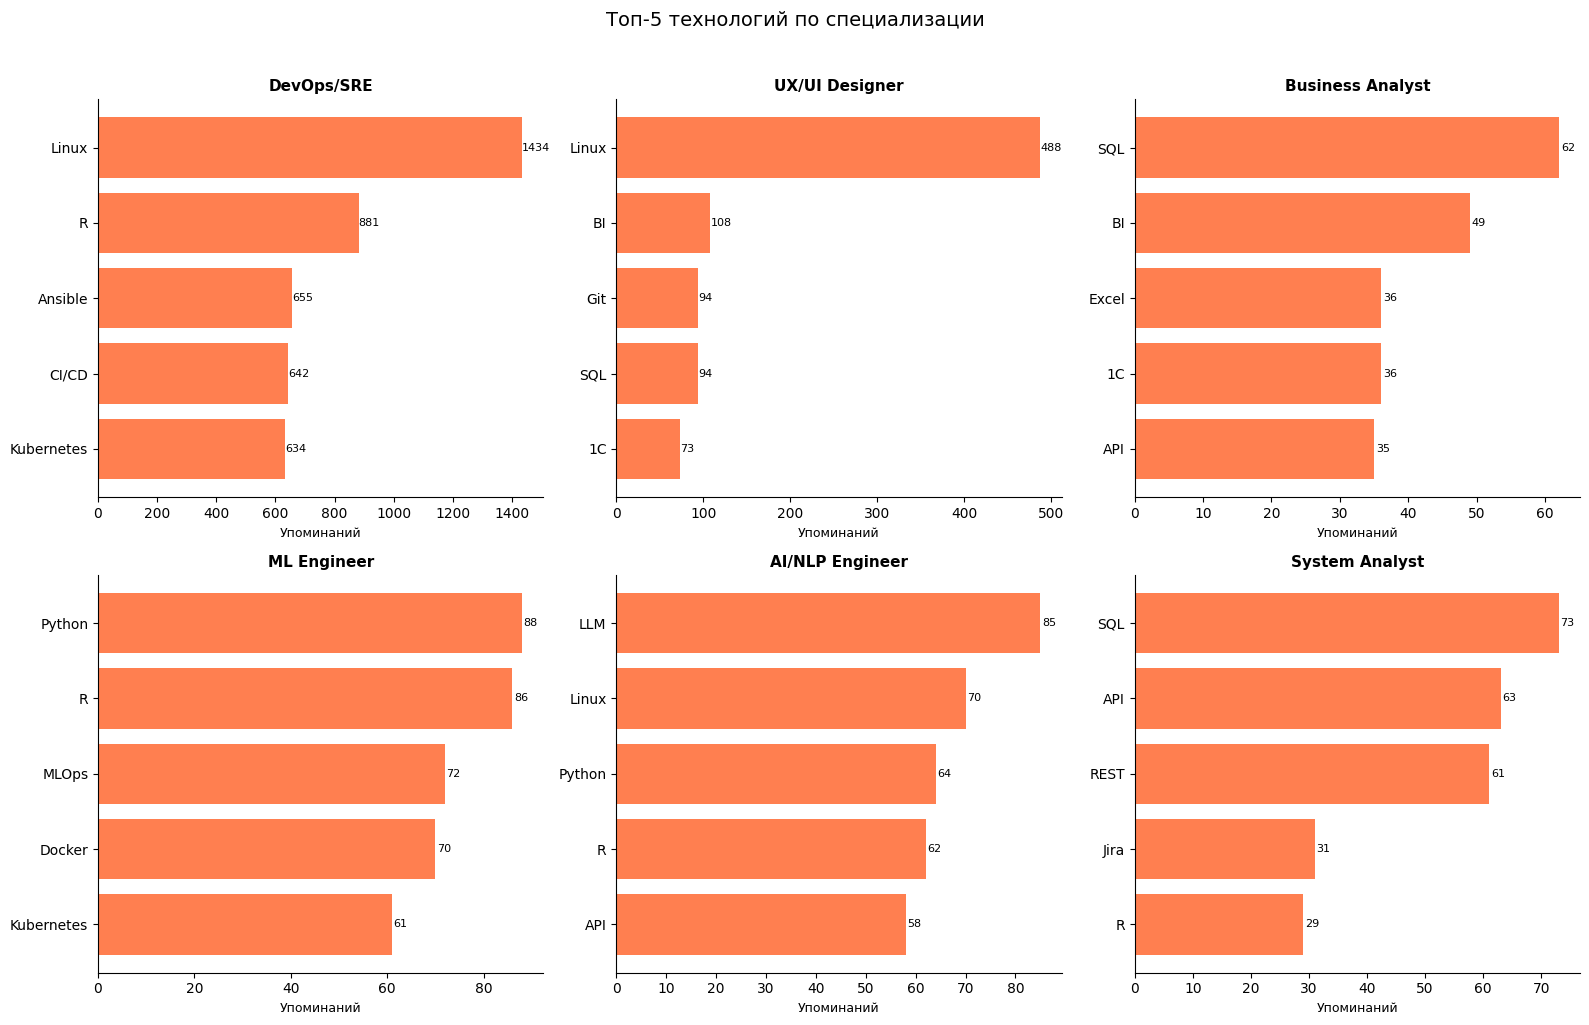

In [67]:
top_n = 5
spec_tech = {}

for spec in df['specialization'].unique():
  df_spec = df[df['specialization'] == spec].dropna(subset=['technologies'])
  techs = Counter([t for row in df_spec['technologies'].str.split(', ') for t in row])
  spec_tech[spec] = techs.most_common(top_n)

top_specs = df['specialization'].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, spec in enumerate(top_specs):
  techs = spec_tech[spec]
  names = [t[0] for t in techs]
  counts = [t[1] for t in techs]

  axes[i].barh(names[::-1], counts[::-1], color='coral')
  axes[i].set_title(spec, fontsize=11, fontweight='bold')
  axes[i].set_xlabel('Упоминаний', fontsize=9)

  for bar, val in zip(axes[i].patches, counts[::-1]):
      axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
  sns.despine(ax=axes[i])

plt.suptitle('Топ-5 технологий по специализации', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

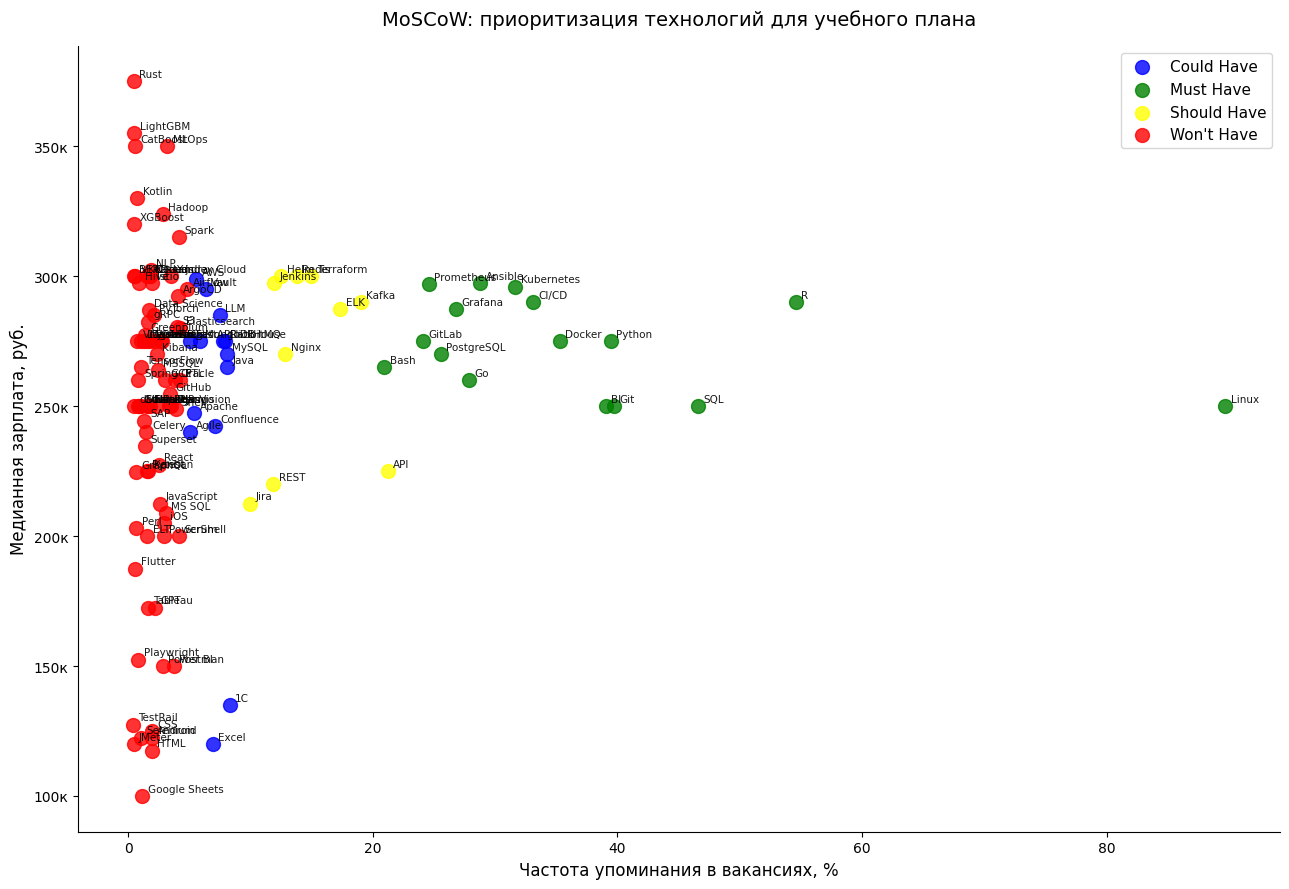

moscow
Could Have     [MySQL, Java, ClickHouse, AWS, Agile, MongoDB,...
Must Have      [Python, Go, R, Docker, Kubernetes, Ansible, G...
Should Have    [Terraform, Redis, Kafka, Nginx, ELK, API, Jen...
Won't Have     [MSSQL, Vite, C++, C#, Node.js, Golang, Kotlin...
Name: technology, dtype: object


In [69]:
total_vac = len(df)

moscow_df = pd.DataFrame([
  {'technology': tech, 'frequency': len(salaries) / total_vac * 100, 'median_salary': pd.Series(salaries).median(), 'count': len(salaries)}
  for tech, salaries in tech_salary.items()
  if len(salaries) >= 10
])

def moscow_category(row):
  if row['frequency'] >= 20 and row['median_salary'] >= 250000:
    return 'Must Have'
  elif row['frequency'] >= 10 and row['median_salary'] >= 200000:
    return 'Should Have'
  elif row['frequency'] >= 5:
    return 'Could Have'
  else:
    return "Won't Have"

moscow_df['moscow'] = moscow_df.apply(moscow_category, axis=1)

colors = {'Must Have': 'green', 'Should Have': 'yellow',
          'Could Have': 'blue', "Won't Have": 'red'}

fig, ax = plt.subplots(figsize=(13, 9))

for category, group in moscow_df.groupby('moscow'):
    ax.scatter(group['frequency'], group['median_salary'], label=category, color=colors[category], s=100, alpha=0.8)
    for x, row in group.iterrows():
        ax.annotate(row['technology'],
                    (row['frequency'], row['median_salary']),
                    fontsize=7.5, alpha=0.9,
                    xytext=(4, 3), textcoords='offset points')

ax.set_title('MoSCoW: приоритизация технологий для учебного плана', fontsize=14, pad=15)
ax.set_xlabel('Частота упоминания в вакансиях, %', fontsize=12)
ax.set_ylabel('Медианная зарплата, руб.', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, k: f'{int(x/1000)}к'))
ax.legend(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

print(moscow_df.groupby('moscow')['technology'].apply(list))